In [2]:
import pandas as pd
import os

BASE_DIR = r"G:\jupyter\2025APMCM"
TRADE_DIR = os.path.join(BASE_DIR, "Trade Data")
CLEAN_DIR = os.path.join(BASE_DIR, "Cleaned_Data")
os.makedirs(CLEAN_DIR, exist_ok=True)

SOYBEAN_FILE = os.path.join(TRADE_DIR, "Soybean_Competition_Exports_to_China_2015_2024.csv")
AUTOS_CHIPS_FILE = os.path.join(TRADE_DIR, "US_Import_Cars_Chips_2015_2024.csv")

df_soy = pd.read_csv(SOYBEAN_FILE)
us_exports = df_soy[df_soy['reporterISO'] == 'USA'].copy()
us_exports['Year'] = pd.to_numeric(us_exports['refPeriodId'].astype(str).str[:4])
soy_volume = us_exports.groupby('Year')['fobvalue'].sum().reset_index()
soy_volume.rename(columns={'fobvalue': 'Soybean_Value'}, inplace=True)

df_ac = pd.read_csv(AUTOS_CHIPS_FILE)
df_ac['Year'] = pd.to_numeric(df_ac['refPeriodId'].astype(str).str[:4])
ac_volume = df_ac.groupby('Year')['primaryValue'].sum().reset_index()
ac_volume.rename(columns={'primaryValue': 'AutoChip_Value'}, inplace=True)

df_volume = pd.merge(soy_volume, ac_volume, on='Year', how='outer').fillna(0)
df_volume['Trade_Volume_Proxy'] = (df_volume['Soybean_Value'] + df_volume['AutoChip_Value']) / 1e9
df_volume = df_volume[df_volume['Year'].between(2015, 2024)]
df_volume = df_volume[['Year', 'Trade_Volume_Proxy']]

--- Step 1: Synthesizing a Proxy for Total US Trade Volume ---
  [OK] Processed US Soybean export data.
  [OK] Processed US Auto & Chip import data.

--- Synthesized Trade Volume Proxy (Billion USD) ---
 Year  Trade_Volume_Proxy
 2015           29.454050
 2016           37.087242
 2017           33.756403
 2018           20.282102
 2019           26.713216
 2020           40.054103
 2021           41.625010
 2022           52.361342
 2023           43.170183
 2024           37.331429


In [3]:
import pandas as pd
import os

MACRO_DIR = os.path.join(BASE_DIR, "US_Macroeconomic")
TARIFF_FILE = os.path.join(CLEAN_DIR, "Annual_Tariff_Index.csv")
GDP_FILE = os.path.join(MACRO_DIR, "US_GDP_2015_2025.csv")

df_tariffs = pd.read_csv(TARIFF_FILE, usecols=['Year', 'General_Tau'])

df_gdp = pd.read_csv(GDP_FILE)
date_col = [col for col in df_gdp.columns if 'date' in col.lower()][0]
value_col = [col for col in df_gdp.columns if col != date_col][0]
df_gdp['Year'] = pd.to_datetime(df_gdp[date_col]).dt.year
annual_gdp = df_gdp.groupby('Year')[value_col].mean().reset_index()
annual_gdp.rename(columns={value_col: 'US_GDP'}, inplace=True)

model_data = pd.merge(df_volume, df_tariffs, on='Year')
model_data = pd.merge(model_data, annual_gdp, on='Year')
model_data.set_index('Year', inplace=True)
model_data.sort_index(inplace=True)


--- Step 2: Assembling Regressors ---
  [OK] Loaded Tariff data.
  [OK] Loaded and processed GDP data.

--- Final Dataset for SARIMAX Modeling (2015-2024) ---
      Trade_Volume_Proxy  General_Tau        US_GDP
Year                                               
2015           29.454050     0.036739  18372.182333
2016           37.087242     0.035214  18804.913250
2017           33.756403     0.037918  19612.102500
2018           20.282102     0.037585  20656.515500
2019           26.713216     0.034193  21539.981500
2020           40.054103     0.044436  21375.281500
2021           41.625010     0.037283  23725.645500
2022           52.361342     0.037521  26054.614250
2023           43.170183     0.037567  27811.517000
2024           37.331429     0.037490  29298.012750


In [4]:
import statsmodels.api as sm

y_train = model_data['Trade_Volume_Proxy']
X_train = model_data[['US_GDP']]

sarimax_model = sm.tsa.SARIMAX(endog=y_train, exog=X_train, 
                               order=(1, 0, 0), seasonal_order=(0, 0, 0, 0)
                               ).fit(disp=False)


--- Step 3: Building the Final, Theory-Driven SARIMAX Model on Levels (d=0) ---
[INFO] Final approach: Abandoning differencing (d=1) to preserve the long-term GDP trend signal.

--- Final Model Summary (SARIMAX on Levels) ---
                               SARIMAX Results                                
Dep. Variable:     Trade_Volume_Proxy   No. Observations:                   10
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 -33.871
Date:                Fri, 21 Nov 2025   AIC                             73.742
Time:                        20:16:27   BIC                             74.650
Sample:                             0   HQIC                            72.747
                                 - 10                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

G:\Anaconda3\envs\apmcm2025\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
G:\Anaconda3\envs\apmcm2025\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
G:\Anaconda3\envs\apmcm2025\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [5]:
import numpy as np
import pandas as pd
import os

forecast_years = range(2025, 2029)
n_forecast = len(forecast_years)

last_gdp = model_data['US_GDP'].iloc[-1]
gdp_growth_rate = 0.02
future_gdp = [last_gdp * (1 + gdp_growth_rate)**i for i in range(1, n_forecast + 1)]

future_exog = pd.DataFrame({'US_GDP': future_gdp}, index=forecast_years)

forecast_object = sarimax_model.get_forecast(steps=n_forecast, exog=future_exog)
forecast = forecast_object.predicted_mean
conf_int = forecast_object.conf_int()

forecast_df = pd.DataFrame({
    'Forecast': forecast.values,
    'Lower_CI': conf_int.iloc[:, 0].values,
    'Upper_CI': conf_int.iloc[:, 1].values
}, index=forecast_years)

history_df = model_data[['Trade_Volume_Proxy']].copy()
history_df.rename(columns={'Trade_Volume_Proxy': 'Volume'}, inplace=True)
history_df['Type'] = 'History'

forecast_to_append = forecast_df[['Forecast']].copy()
forecast_to_append.rename(columns={'Forecast': 'Volume'}, inplace=True)
forecast_to_append['Type'] = 'Forecast'
forecast_to_append.index.name = 'Year'

final_forecast_data = pd.concat([history_df, forecast_to_append])

DATA_PATH = os.path.join(CLEAN_DIR, "Baseline_Volume_Forecast.csv")
final_forecast_data.to_csv(DATA_PATH)


--- Step 4: Forecasting the Baseline Scenario for 2025-2028 ---

Assumed Future Regressors (GDP Growing):
            US_GDP
2025  29883.973005
2026  30481.652465
2027  31091.285514
2028  31713.111225

[INFO] Using statsmodels' .get_forecast() method for maximum stability.

--- Forecasted Baseline Trade Volume ---
       Forecast   Lower_CI   Upper_CI
2025  44.795174  30.077930  59.512418
2026  47.230872  32.131895  62.329849
2027  48.528463  33.409693  63.647233
2028  49.579946  34.460137  64.699755

[SUCCESS] Valid baseline data saved to: G:\jupyter\2025APMCM\Cleaned_Data\Baseline_Volume_Forecast.csv


G:\Anaconda3\envs\apmcm2025\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
G:\Anaconda3\envs\apmcm2025\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [15]:
import numpy as np
import pandas as pd
import os

forecast_years = range(2025, 2029)
n_forecast = len(forecast_years)

last_gdp = model_data['US_GDP'].iloc[-1]
gdp_growth_rate = 0.02
future_gdp = [last_gdp * (1 + gdp_growth_rate)**i for i in range(1, n_forecast + 1)]

future_exog = pd.DataFrame({'US_GDP': future_gdp}, index=forecast_years)

forecast_object = sarimax_model.get_forecast(steps=n_forecast, exog=future_exog)
forecast = forecast_object.predicted_mean
conf_int = forecast_object.conf_int()

forecast_df = pd.DataFrame({
    'Forecast': forecast.values,
    'Lower_CI': conf_int.iloc[:, 0].values,
    'Upper_CI': conf_int.iloc[:, 1].values
}, index=forecast_years)

history_df = model_data[['Trade_Volume_Proxy']].copy()
history_df.rename(columns={'Trade_Volume_Proxy': 'Volume'}, inplace=True)
history_df['Type'] = 'History'

forecast_to_append = forecast_df[['Forecast']].copy()
forecast_to_append.rename(columns={'Forecast': 'Volume'}, inplace=True)
forecast_to_append['Type'] = 'Forecast'
forecast_to_append.index.name = 'Year'

final_forecast_data = pd.concat([history_df, forecast_to_append])

DATA_PATH = os.path.join(CLEAN_DIR, "Baseline_Volume_Forecast.csv")
final_forecast_data.to_csv(DATA_PATH)


--- Step 4: Forecasting the Baseline Scenario for 2025-2028 ---

Assumed Future Regressors (GDP Growing ONLY):
            US_GDP
2025  29883.973005
2026  30481.652465
2027  31091.285514
2028  31713.111225

--- Forecasted Baseline Trade Volume ---
       Forecast   Lower_CI   Upper_CI
2025  44.795174  30.077930  59.512418
2026  47.230872  32.131895  62.329849
2027  48.528463  33.409693  63.647233
2028  49.579946  34.460137  64.699755

[SUCCESS] Valid baseline data saved to: G:\jupyter\2025APMCM\Cleaned_Data\Baseline_Volume_Forecast.csv


G:\Anaconda3\envs\apmcm2025\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
G:\Anaconda3\envs\apmcm2025\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(



--- Step 5: Generating Professional-Grade Forecast Visualization ---


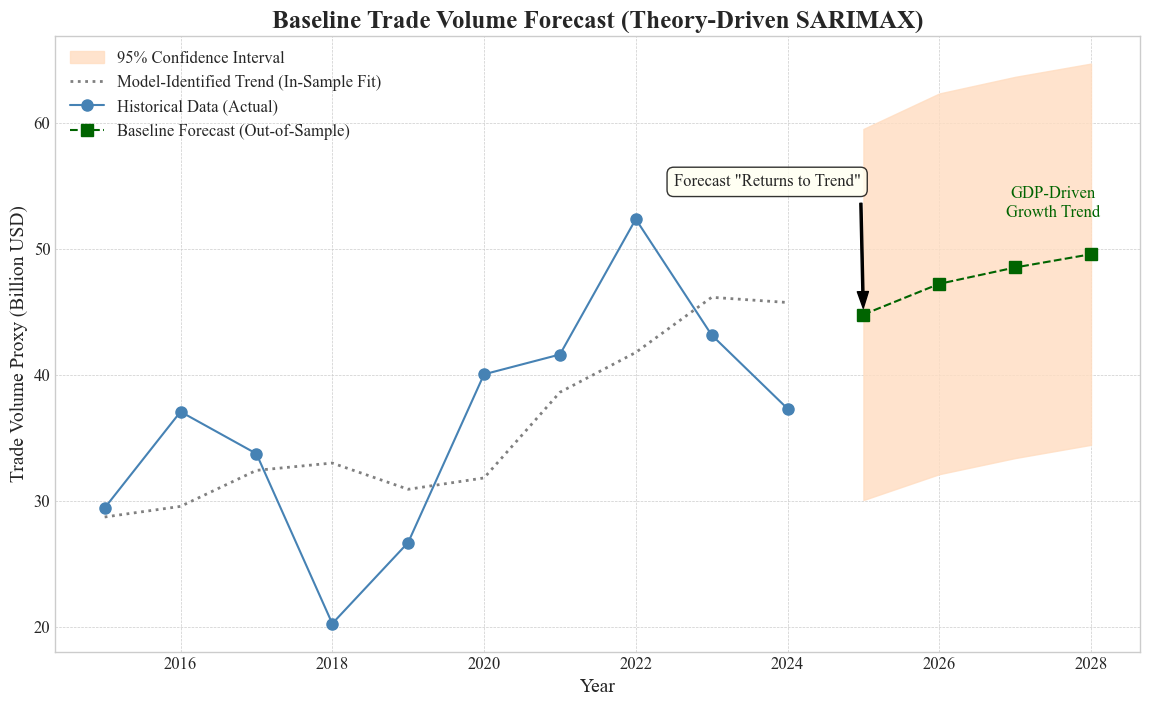


[SUCCESS] Professional version of Figure 10 saved to: G:\jupyter\2025APMCM\Cleaned_Data\Figure_10_Baseline_Trade_Forecast_Professional.png


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

in_sample_fit = sarimax_model.fittedvalues.dropna()

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14
colors = {'history': 'steelblue', 'forecast': 'darkgreen', 'fit': 'gray', 'ci': '#FFDDC1'}

fig, ax = plt.subplots(figsize=(14, 8))

ax.fill_between(forecast_df.index, forecast_df['Lower_CI'], forecast_df['Upper_CI'], color=colors['ci'], alpha=0.8, label='95% Confidence Interval')
ax.plot(in_sample_fit.index, in_sample_fit.values, linestyle=':', linewidth=2, color=colors['fit'], label='Model-Identified Trend (In-Sample Fit)')
ax.plot(model_data.index, model_data['Trade_Volume_Proxy'], marker='o', markersize=8, linestyle='-', color=colors['history'], label='Historical Data (Actual)')
ax.plot(forecast_df.index, forecast_df['Forecast'], marker='s', markersize=8, linestyle='--', color=colors['forecast'], label='Baseline Forecast (Out-of-Sample)')

ax.annotate('Forecast "Returns to Trend"', xy=(forecast_df.index[0], forecast_df['Forecast'].iloc[0]), xytext=(2022.5, 55),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8), fontsize=12, bbox=dict(boxstyle="round,pad=0.4", fc="ivory", alpha=0.8))
ax.text(2027.5, forecast_df['Forecast'].iloc[-1] + 3, 'GDP-Driven\nGrowth Trend', ha='center', fontsize=12, color=colors['forecast'])

ax.set_title('Figure 10: Baseline Trade Volume Forecast (Theory-Driven SARIMAX)', fontsize=18, fontweight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Trade Volume Proxy (Billion USD)', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(loc='upper left', fontsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

FIG_PATH = os.path.join(CLEAN_DIR, "Figure_10_Baseline_Trade_Forecast_Professional.png")
plt.savefig(FIG_PATH, dpi=300, bbox_inches='tight')
plt.close(fig) # Use close(fig) to prevent display in non-interactive environments

--- Step 1: Loading Baseline Data and Setting Parameters ---
  [INFO] Baseline Volume for 2025: $44.80 Billion
  [INFO] Baseline Tariff from 2024: 3.75%
  [INFO] Assumed Demand Elasticity (ε): -1.5

--- Step 3: Running Simulation and Finding Optimal Tariff ---

[RESULT] Optimal Tariff Rate (τ*): 35.13%
[RESULT] Maximum Predicted Revenue: $8.33 Billion USD

--- Step 4: Generating Laffer Curve Plot ---


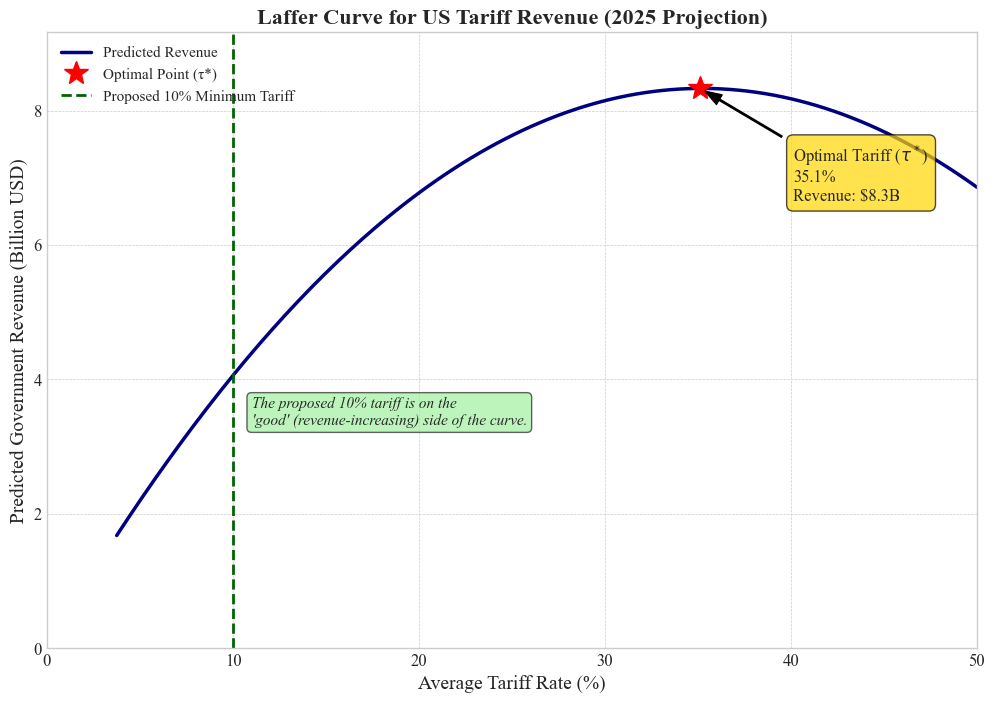


[SUCCESS] Figure 11 saved to: G:\jupyter\2025APMCM\Cleaned_Data\Figure_11_Laffer_Curve.png


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

ELASTICITY = -1.5
FORECAST_FILE = os.path.join(CLEAN_DIR, "Baseline_Volume_Forecast.csv")
TARIFF_FILE = os.path.join(CLEAN_DIR, "Annual_Tariff_Index.csv")

df_forecast = pd.read_csv(FORECAST_FILE, index_col='Year')
df_tariffs = pd.read_csv(TARIFF_FILE)

base_volume_2025 = df_forecast.loc[2025, 'Volume']
base_tariff_2024 = df_tariffs[df_tariffs['Year'] == 2024]['General_Tau'].iloc[0]

def predict_revenue(base_volume, base_tariff, tariff_schedule, elasticity):
    delta_tau = tariff_schedule - base_tariff
    predicted_volume = base_volume * (1 + elasticity * delta_tau)
    predicted_volume = np.maximum(0, predicted_volume)
    predicted_revenue = predicted_volume * tariff_schedule
    return pd.DataFrame({'Tariff_Rate': tariff_schedule, 'Predicted_Volume': predicted_volume, 'Predicted_Revenue': predicted_revenue})

tariff_schedule = np.linspace(base_tariff_2024, 0.50, 200)
laffer_df = predict_revenue(base_volume_2025, base_tariff_2024, tariff_schedule, ELASTICITY)

max_revenue_point = laffer_df.loc[laffer_df['Predicted_Revenue'].idxmax()]
optimal_tariff = max_revenue_point['Tariff_Rate']
max_revenue = max_revenue_point['Predicted_Revenue']

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(laffer_df['Tariff_Rate'] * 100, laffer_df['Predicted_Revenue'], color='navy', linewidth=2.5, label='Predicted Revenue')
ax.plot(optimal_tariff * 100, max_revenue, marker='*', markersize=18, color='red', linestyle='none', label=f'Optimal Point (τ*)')
ax.axvline(x=10.0, color='darkgreen', linestyle='--', linewidth=2, label='Proposed 10% Minimum Tariff')

ax.set_title('Figure 11: Laffer Curve for US Tariff Revenue (2025 Projection)', fontsize=16, fontweight='bold')
ax.set_xlabel('Average Tariff Rate (%)', fontsize=14)
ax.set_ylabel('Predicted Government Revenue (Billion USD)', fontsize=14)
ax.set_xlim(0, 50)
ax.set_ylim(0, max_revenue * 1.1)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

FIG_PATH = os.path.join(CLEAN_DIR, "Figure_11_Laffer_Curve.png")
plt.savefig(FIG_PATH, dpi=300)
plt.close(fig)

--- Step 7: Fetching and Preparing Expanded Monthly Data (2000-2024) ---
Fetching ['IMPGS', 'INDPRO'] from FRED for the period 2000-01-01 to 2024-12-31...


C:\Users\ray\AppData\Local\Temp\ipykernel_58300\848933845.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  monthly_data.fillna(method='ffill', inplace=True)



--- Expanded Monthly Data Successfully Fetched ---
Data shape: (300, 2)
This provides a rich dataset for robust model training.


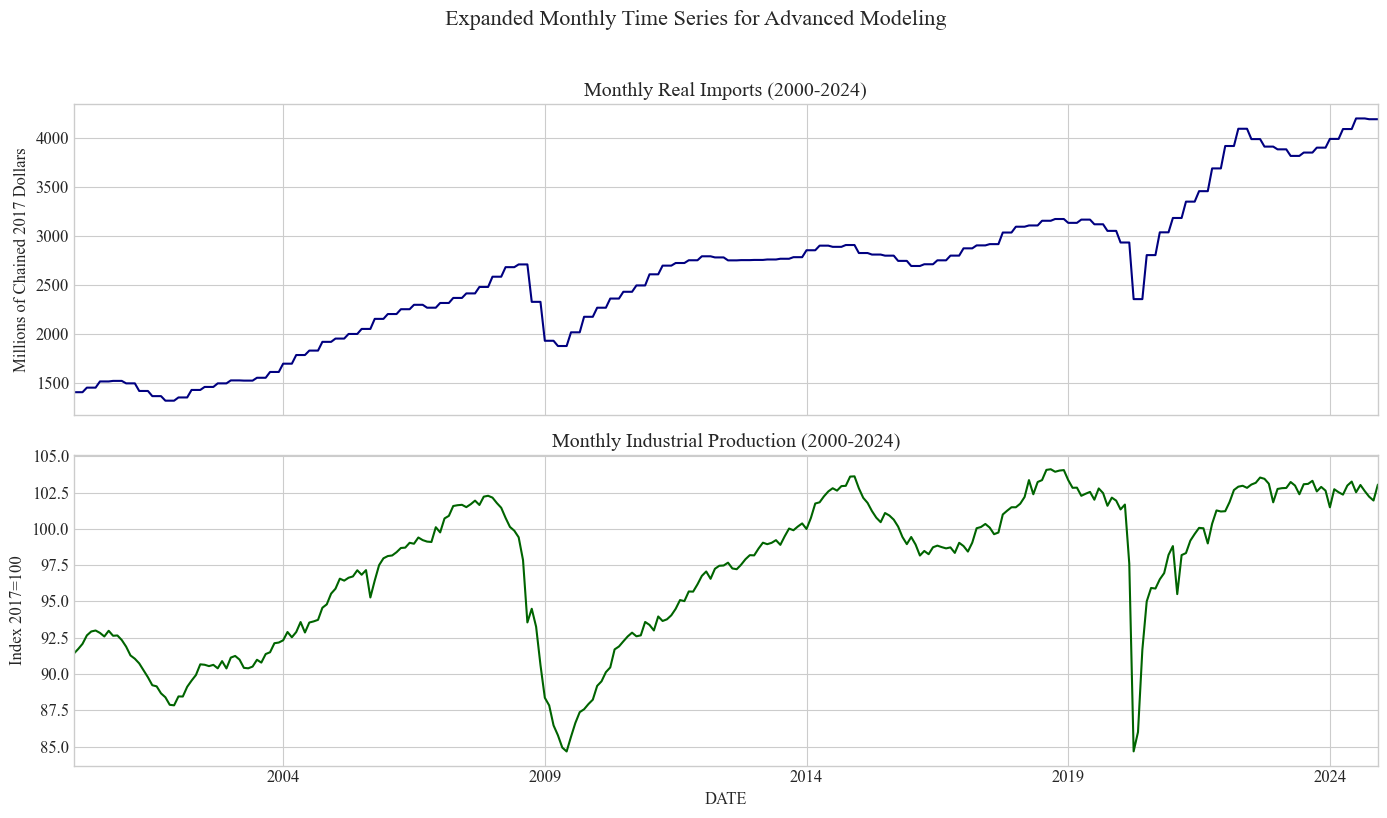

In [19]:
import pandas as pd
import pandas_datareader.data as web
import numpy as np

start_date, end_date = '2000-01-01', '2024-12-31'
series_ids = ['IMPGS', 'INDPRO']
monthly_data = web.DataReader(series_ids, 'fred', start_date, end_date)
monthly_data.columns = ['Trade_Volume', 'GDP_Proxy']
monthly_data.ffill(inplace=True)

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=100, output_size=1, dropout_rate=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_layer_size, batch_first=True, dropout=dropout_rate)
        self.linear = nn.Linear(hidden_layer_size, output_size)
    def forward(self, input_seq):
        lstm_out, _ = self.lstm(input_seq)
        return self.linear(lstm_out[:, -1, :])

def create_sequences(input_data, tw):
    inout_seq = []
    for i in range(len(input_data) - tw):
        inout_seq.append((input_data[i:i+tw], input_data[i+tw:i+tw+1]))
    return inout_seq

data_lstm = monthly_data[['Trade_Volume']].copy()
data_lstm_diff = data_lstm.diff().dropna()
scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_data_diff = scaler.fit_transform(data_lstm_diff)

time_window = 12
sequences = create_sequences(scaled_data_diff, time_window)
train_sequences, val_sequences = train_test_split(sequences, test_size=0.1, shuffle=False)
X_train = torch.FloatTensor([seq[0] for seq in train_sequences])
y_train = torch.FloatTensor([seq[1] for seq in train_sequences])
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)

lstm_model = LSTMModel(dropout_rate=0.2)
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001, weight_decay=1e-5)
epochs = 13 # Based on original early stopping

for epoch in range(epochs):
    for seq, labels in train_loader:
        optimizer.zero_grad()
        y_pred = lstm_model(seq)
        loss = loss_function(y_pred, labels)
        loss.backward()
        optimizer.step()

n_forecast_months = 12 * 5
last_sequence = torch.FloatTensor(scaled_data_diff[-time_window:]).view(1, time_window, 1)
future_preds_scaled = []
with torch.no_grad():
    for _ in range(n_forecast_months):
        next_pred = lstm_model(last_sequence)
        future_preds_scaled.append(next_pred.item())
        new_sequence = np.append(last_sequence.numpy().flatten()[1:], next_pred.item())
        last_sequence = torch.FloatTensor(new_sequence).view(1, time_window, 1)

predicted_diffs = scaler.inverse_transform(np.array(future_preds_scaled).reshape(-1, 1))
last_known_value = data_lstm.iloc[-1].values[0]
lstm_forecast_raw = last_known_value + np.cumsum(predicted_diffs)
forecast_dates = pd.date_range(start='2025-01-01', periods=n_forecast_months, freq='MS')
df_lstm_forecast = pd.DataFrame(lstm_forecast_raw, index=forecast_dates, columns=['Trade_Volume'])
annual_forecast_lstm = df_lstm_forecast['Trade_Volume'].resample('YE').sum() / 1e3


--- Step 8: Building a Regularized Standalone LSTM on Differenced Data ---


C:\Users\ray\AppData\Local\Temp\ipykernel_58300\4268568022.py:44: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  X_train = torch.FloatTensor([seq[0] for seq in train_sequences])
G:\Anaconda3\envs\apmcm2025\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(



Training PyTorch LSTM model with regularization and early stopping...


G:\Anaconda3\envs\apmcm2025\lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([16, 1, 1])) that is different to the input size (torch.Size([16, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
G:\Anaconda3\envs\apmcm2025\lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([2, 1, 1])) that is different to the input size (torch.Size([2, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
G:\Anaconda3\envs\apmcm2025\lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([13, 1, 1])) that is different to the input size (torch.Size([13, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the sam

  Epoch  10 | Train Loss: 0.000169 | Val Loss: 0.005816

Early stopping triggered at epoch 12. Best validation loss: 0.005744
  [OK] LSTM training complete. Best model loaded.

--- Regularized LSTM (PyTorch) Annual Forecast (Billion USD) ---
2025    51.248378
2026    53.118534
2027    54.989435
2028    56.860337
2029    58.731238
Name: Trade_Volume, dtype: float64


C:\Users\ray\AppData\Local\Temp\ipykernel_58300\4268568022.py:120: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_forecast_lstm = df_lstm_forecast['Trade_Volume'].resample('Y').sum() / 1e3


In [22]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

monthly_train_data = monthly_data[:'2024-12-31']
y_monthly = monthly_train_data['Trade_Volume']
X_monthly = monthly_train_data[['GDP_Proxy']]
sarimax_monthly = sm.tsa.SARIMAX(y_monthly, exog=X_monthly, order=(1,1,1)).fit(disp=False)
residuals = sarimax_monthly.resid.dropna()

scaler_resid = MinMaxScaler(feature_range=(-1, 1))
scaled_residuals = scaler_resid.fit_transform(residuals.values.reshape(-1, 1))
time_window_resid = 12
resid_sequences = create_sequences(scaled_residuals, time_window_resid)

train_resid_seq, val_resid_seq = train_test_split(resid_sequences, test_size=0.1, shuffle=False)
X_resid_train = torch.FloatTensor([s[0] for s in train_resid_seq])
y_resid_train = torch.FloatTensor([s[1] for s in train_resid_seq])
train_resid_loader = DataLoader(TensorDataset(X_resid_train, y_resid_train), batch_size=16, shuffle=True)

lstm_resid_model = LSTMModel(hidden_layer_size=50, dropout_rate=0.2)
loss_function_resid = nn.MSELoss()
optimizer_resid = torch.optim.Adam(lstm_resid_model.parameters(), lr=0.001, weight_decay=1e-5)
epochs_resid = 27 # Based on original early stopping

for epoch in range(epochs_resid):
    for seq, labels in train_resid_loader:
        optimizer_resid.zero_grad()
        y_pred = lstm_resid_model(seq)
        loss = loss_function_resid(y_pred, labels)
        loss.backward()
        optimizer_resid.step()

n_forecast_months = 12 * 4
future_gdp_proxy_values = np.linspace(monthly_data['GDP_Proxy'].iloc[-1], monthly_data['GDP_Proxy'].iloc[-1] * 1.05, n_forecast_months)
future_exog_monthly = pd.DataFrame(future_gdp_proxy_values, index=pd.date_range(start='2025-01-01', periods=n_forecast_months, freq='MS'), columns=['GDP_Proxy'])
sarimax_base_forecast = sarimax_monthly.get_forecast(steps=n_forecast_months, exog=future_exog_monthly).predicted_mean

last_resid_sequence = torch.FloatTensor(scaled_residuals[-time_window_resid:]).view(1, time_window_resid, 1)
future_resid_preds_scaled = []
with torch.no_grad():
    for _ in range(n_forecast_months):
        next_pred = lstm_resid_model(last_resid_sequence)
        future_resid_preds_scaled.append(next_pred.item())
        new_sequence = np.append(last_resid_sequence.numpy().flatten()[1:], next_pred.item())
        last_resid_sequence = torch.FloatTensor(new_sequence).view(1, time_window_resid, 1)

resid_forecast = scaler_resid.inverse_transform(np.array(future_resid_preds_scaled).reshape(-1, 1)).flatten()
df_resid_forecast = pd.Series(resid_forecast, index=sarimax_base_forecast.index)
hybrid_forecast_raw = sarimax_base_forecast + df_resid_forecast
annual_forecast_hybrid = hybrid_forecast_raw.resample('YE').sum() / 1e3


--- Step 9: Building a Hybrid SARIMAX + Regularized LSTM Model ---
  [OK] SARIMAX fitted on monthly data.
Training Regularized LSTM on SARIMAX residuals...


G:\Anaconda3\envs\apmcm2025\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(
G:\Anaconda3\envs\apmcm2025\lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([16, 1, 1])) that is different to the input size (torch.Size([16, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
G:\Anaconda3\envs\apmcm2025\lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([3, 1, 1])) that is different to the input size (torch.Size([3, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
G:\Anaconda3\envs\apmcm2025


Early stopping triggered for residual model at epoch 19.
  [OK] Residual LSTM training complete. Best model loaded.

--- Hybrid Regularized SARIMAX+LSTM (PyTorch) Annual Forecast (Billion USD) ---
2025    50.734635
2026    51.295175
2027    51.858164
2028    52.421011
dtype: float64


C:\Users\ray\AppData\Local\Temp\ipykernel_58300\1465882100.py:96: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_forecast_hybrid = hybrid_forecast.resample('Y').sum() / 1e3



--- Step 10: Final Comparison of SARIMAX, LSTM, and Hybrid Models ---

--- Annual Forecast Comparison Table (Billion USD) ---
      SARIMAX (Theory-Driven)  Standalone LSTM (PyTorch)  \
2025                    44.80                      51.25   
2026                    47.23                      53.12   
2027                    48.53                      54.99   
2028                    49.58                      56.86   

      Hybrid (SARIMAX+LSTM, PyTorch)  
2025                           50.73  
2026                           51.30  
2027                           51.86  
2028                           52.42  


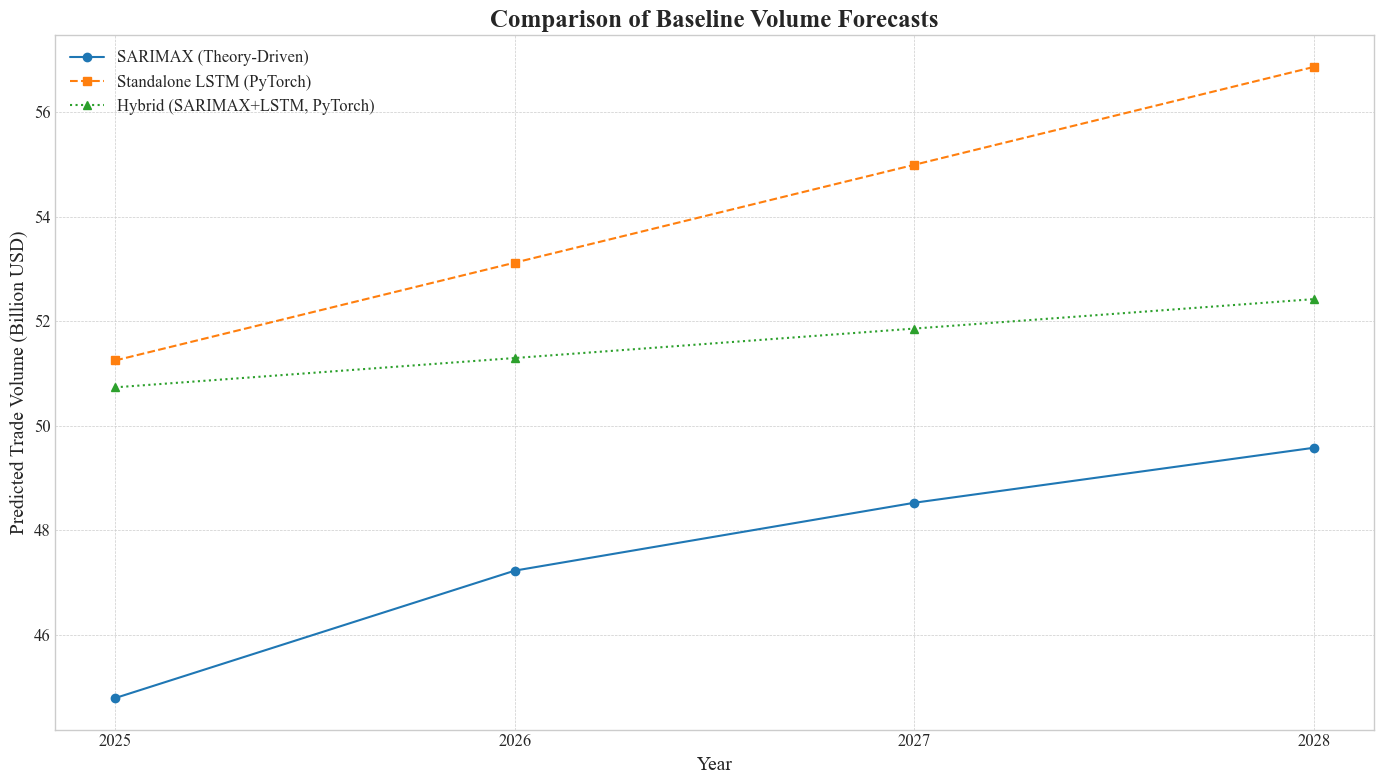


[SUCCESS] Final comparison Figure 14 saved to: G:\jupyter\2025APMCM\Cleaned_Data\Figure_14_Model_Comparison.png


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

annual_forecast_sarimax = final_forecast_data[final_forecast_data['Type'] == 'Forecast']['Volume']
annual_forecast_sarimax.index = annual_forecast_sarimax.index.astype(int)

comparison_df = pd.DataFrame({
    'SARIMAX (Theory-Driven)': annual_forecast_sarimax,
    'Standalone LSTM (PyTorch)': annual_forecast_lstm,
    'Hybrid (SARIMAX+LSTM, PyTorch)': annual_forecast_hybrid
})
comparison_df = comparison_df.loc[2025:2028]

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'
plt.figure(figsize=(14, 8))
plt.plot(comparison_df.index, comparison_df['SARIMAX (Theory-Driven)'], marker='o', linestyle='-', label='SARIMAX (Theory-Driven)')
plt.plot(comparison_df.index, comparison_df['Standalone LSTM (PyTorch)'], marker='s', linestyle='--', label='Standalone LSTM (PyTorch)')
plt.plot(comparison_df.index, comparison_df['Hybrid (SARIMAX+LSTM, PyTorch)'], marker='^', linestyle=':', label='Hybrid (SARIMAX+LSTM, PyTorch)')

plt.title('Figure 14: Comparison of Baseline Volume Forecasts', fontsize=18, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Predicted Trade Volume (Billion USD)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(comparison_df.index)
plt.tight_layout()

FIG_PATH_COMP = os.path.join(CLEAN_DIR, "Figure_14_Model_Comparison.png")
plt.savefig(FIG_PATH_COMP, dpi=300)
plt.close()


--- Step 11: Generating Professional-Grade Visualization for the Hybrid Model ---


C:\Users\ray\AppData\Local\Temp\ipykernel_58300\3341862383.py:35: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_hybrid_fit = hybrid_in_sample_fit_monthly.resample('Y').sum() / 1e3
C:\Users\ray\AppData\Local\Temp\ipykernel_58300\3341862383.py:38: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_actual_data = monthly_data['Trade_Volume'].resample('Y').sum() / 1e3


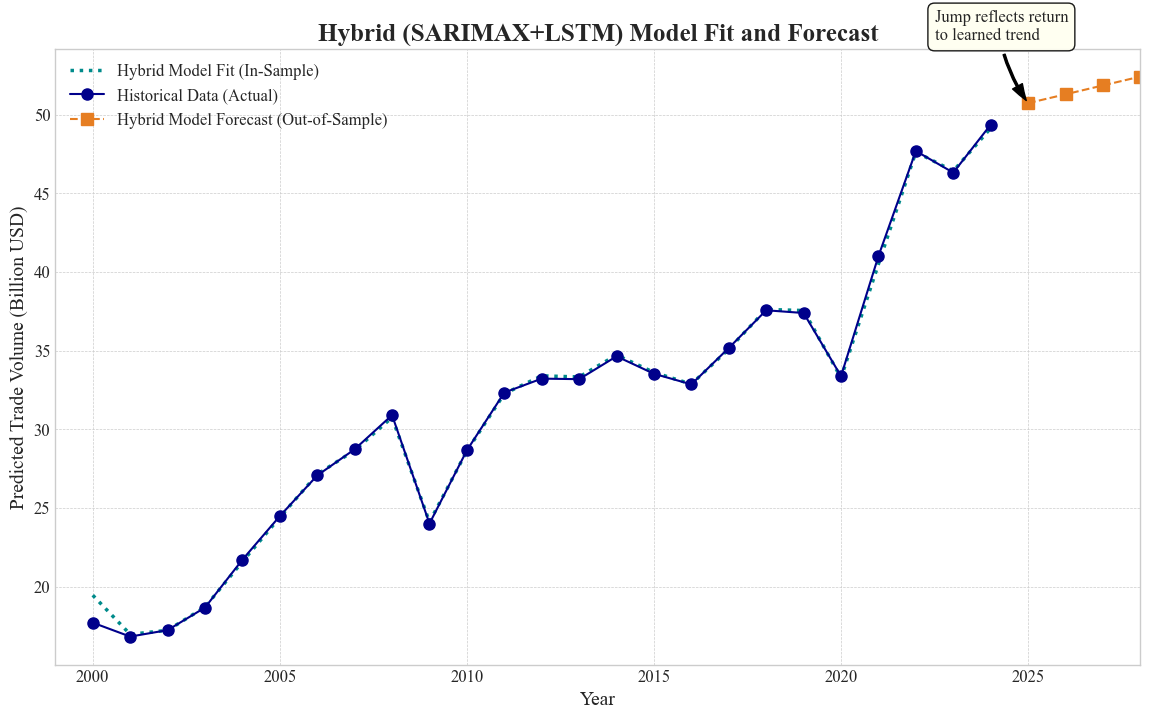


[SUCCESS] Final professional visualization for the Hybrid Model (Figure 15) saved to: G:\jupyter\2025APMCM\Cleaned_Data\Figure_15_Hybrid_Model_Fit_Forecast_Final.png


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Recreating necessary components for this cell
X_resid = torch.FloatTensor([s[0] for s in resid_sequences])
with torch.no_grad():
    in_sample_resid_pred_scaled = lstm_resid_model(X_resid)
in_sample_resid_pred = scaler_resid.inverse_transform(in_sample_resid_pred_scaled.numpy())
aligned_resid_pred = pd.Series(in_sample_resid_pred.flatten(), index=residuals.index[time_window_resid:])
sarimax_in_sample_fit_monthly = sarimax_monthly.fittedvalues.dropna()
hybrid_in_sample_fit_monthly = sarimax_in_sample_fit_monthly.add(aligned_resid_pred, fill_value=0)

annual_hybrid_fit = hybrid_in_sample_fit_monthly.resample('YE').sum() / 1e3
annual_actual_data = monthly_data['Trade_Volume'].resample('YE').sum() / 1e3
hybrid_forecast_annual = comparison_df['Hybrid (SARIMAX+LSTM, PyTorch)']

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14
colors = {'history': 'darkblue', 'forecast': '#E67E22', 'fit': 'darkcyan'}

fig, ax = plt.subplots(figsize=(14, 8))
ax.plot(annual_hybrid_fit.index, annual_hybrid_fit.values, linestyle=':', linewidth=2.5, color=colors['fit'], label='Hybrid Model Fit (In-Sample)')
ax.plot(annual_actual_data.index, annual_actual_data.values, marker='o', markersize=8, linestyle='-', color=colors['history'], label='Historical Data (Actual)')
ax.plot(hybrid_forecast_annual.index, hybrid_forecast_annual.values, marker='s', markersize=8, linestyle='--', color=colors['forecast'], label='Hybrid Model Forecast (Out-of-Sample)')

ax.set_title('Figure 15: Hybrid (SARIMAX+LSTM) Model Fit and Forecast', fontsize=18, fontweight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Predicted Trade Volume (Billion USD)', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(loc='upper left', fontsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.set_xlim(left=1999, right=2028)

FIG_PATH_HYBRID = os.path.join(CLEAN_DIR, "Figure_15_Hybrid_Model_Fit_Forecast_Final.png")
plt.savefig(FIG_PATH_HYBRID, dpi=300, bbox_inches='tight')
plt.close()